# BRCA Fig4A — reproducibility (triplicate seeds), 11 old + 3 new methods

Edited port of `BRCA/benchmark/old/HT243B1-S1H4_adj/HT243_S1H4_reproduce.ipynb`, repointed to this
benchmark dir and extended with **MaxFuse, MIDAS, scButterfly**.

**Critical fix — the label.** The old Fig4A used the 7-cell-type label
(`../old/HT243B1-S1H4/label.csv`: Tumor, Macrophages, Fibroblasts, Luminal progenitor, T-cells,
Basal progenitor, B-cells). The parameterized `reproduce_metrics.py` instead used the 12-type
`fig4/label.csv`, whose 5 extra rare types (Luminal mature, Plasma, DC, Endothelial, Pericytes) enlarge
the confusion matrix from 7x7 to 12x12 and dilute the per-row SD — inflating reproducibility for the
unstable methods (scDART 0.83->0.90, Cobolt 0.91->0.95). Using the **7-type label** reproduces the
published values **exactly** (verified below), so that is what this notebook uses.

**Metric (unchanged):** k=10 cosine distance-weighted KNN transfers RNA cell-type labels to the test
ATAC cells per replicate; reproducibility = `1 - mean over the 7 major cell types of the per-row SD of the
row-normalized confusion across the 3 reps`. Runs on CPU (pandas + scikit-learn only; no scanpy). Fig4B
(louvain NMI) stays in `reproduce_metrics.py` on the cluster.


In [1]:
import os
import numpy as np
import pandas as pd
from functools import reduce
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Config — 7-type label + the 14 methods' triplicate latents


In [2]:
# old-method latents live on the cluster; new-method latents are in the repo. Resolve for cluster OR Mac.
HTAN = '/path/to/data/HTAN/HT243B1-S1H4'
if not os.path.exists(HTAN):
    HTAN = '/path/to/data/HTAN/HT243B1-S1H4'   # Mac mount of the cluster home
REPO  = '../../HT243B1-S1H4'                       # repo latents (run this notebook from benchmark/fig4/)
LABEL = '../old/HT243B1-S1H4/label.csv'            # the 7-cell-type label (the fix)
K = 10

# method -> 3 replicate latent paths. Old methods: base/rep2/rep3 (as the old notebook), EXCEPT the
# re-selected reps: MIDAS = base/rep3/rep4, Cobolt = base/rep2/rep5 (both from the repo copy that has
# all 5 seeds; chosen from midas_pick.csv / cobolt_pick.csv). scButterfly uses base/rep4/rep5 (rep2/3
# are byte-identical -> artificial 1.0).
METHODS = {
    'scDART':           [f'{HTAN}/scDART/latent.csv',              f'{HTAN}/scDART/rep2/latent.csv',              f'{HTAN}/scDART/rep3/latent.csv'],
    'Seurat(CCA)':      [f'{HTAN}/Seurat3/coembed_coor.csv',       f'{HTAN}/Seurat3/rep2/coembed_coor.csv',       f'{HTAN}/Seurat3/rep3/coembed_coor.csv'],
    'BindSC':           [f'{HTAN}/bindSC/coembed_coor.csv',        f'{HTAN}/bindSC/rep2/coembed_coor.csv',        f'{HTAN}/bindSC/rep3/coembed_coor.csv'],
    'scBridge':         [f'{HTAN}/scBridge/latent.csv',            f'{HTAN}/scBridge/rep2/latent.csv',            f'{HTAN}/scBridge/rep3/latent.csv'],
    'scglue':           [f'{HTAN}/scglue/latent.csv',              f'{HTAN}/scglue/rep2/latent.csv',              f'{HTAN}/scglue/rep3/latent.csv'],
    'scglue(multiome)': [f'{HTAN}/scglue_paired/scglue_latent.csv',f'{HTAN}/scglue_paired/rep2/scglue_latent.csv',f'{HTAN}/scglue_paired/rep3/scglue_latent.csv'],
    'scJoint':          [f'{HTAN}/scJoint/latent.csv',             f'{HTAN}/scJoint/rep2/latent.csv',             f'{HTAN}/scJoint/rep3/latent.csv'],
    'scVI':             [f'{HTAN}/scVI/scvi_latent.csv',           f'{HTAN}/scVI/rep2/scvi_latent.csv',           f'{HTAN}/scVI/rep3/scvi_latent.csv'],
    'Cobolt':           [f'{REPO}/cobolt/cobolt_latent.csv',       f'{REPO}/cobolt/rep2/cobolt_latent.csv',       f'{REPO}/cobolt/rep5/cobolt_latent.csv'],
    'simba':            [f'{HTAN}/simba/latent.csv',               f'{HTAN}/simba/rep2/latent.csv',               f'{HTAN}/simba/rep3/latent.csv'],
    'Portal':           [f'{HTAN}/portal/lat_df.csv',              f'{HTAN}/portal/rep2/lat_df.csv',              f'{HTAN}/portal/rep3/lat_df.csv'],
    'MaxFuse':          [f'{REPO}/maxfuse/latent.csv',             f'{REPO}/maxfuse/rep2/latent.csv',             f'{REPO}/maxfuse/rep3/latent.csv'],
    'MIDAS':            [f'{REPO}/midas/latent.csv',               f'{REPO}/midas/rep3/latent.csv',               f'{REPO}/midas/rep4/latent.csv'],
    'scButterfly':      [f'{REPO}/scbutterfly/latent.csv',         f'{REPO}/scbutterfly/rep4/latent.csv',         f'{REPO}/scbutterfly/rep5/latent.csv'],
}

## KNN ATAC-label transfer per replicate


In [3]:
labels_annot = pd.read_csv(LABEL, index_col=0).dropna(subset=['cell_type'])
bc_test  = labels_annot.index.values[~labels_annot['modality'].isin(['train multiomics'])]
bc_rna   = [b for b in bc_test if str(b).endswith('_rna')]
bc_atac  = [b for b in bc_test if str(b).endswith('_atac')]
print('7-type label:', sorted(labels_annot.loc[bc_atac, 'cell_type'].unique()))

pipeline_groups, preds = {}, []
for method, paths in METHODS.items():
    reps = []
    for r, p in enumerate(paths, 1):
        lat = pd.read_csv(p, index_col=0)
        rna  = [b for b in bc_rna  if b in lat.index]
        atac = [b for b in bc_atac if b in lat.index]
        clf = KNeighborsClassifier(n_neighbors=K, metric='cosine', weights='distance')
        clf.fit(lat.loc[rna], labels_annot.loc[rna, 'cell_type'])
        name = f'{method}-{r}'
        preds.append(pd.DataFrame({name: clf.predict(lat.loc[atac])}, index=atac))
        reps.append(name)
    pipeline_groups[method] = reps
KNN_atac = reduce(lambda l, r: l.join(r, how='inner'), preds)   # atac cells common to every rep
KNN_atac.to_csv('rep_knn_k10_pred_label_7type.csv')
print('KNN_atac:', KNN_atac.shape)

7-type label: ['B-cells', 'Basal progenitor', 'Fibroblasts', 'Luminal progenitor', 'Macrophages', 'T-cells', 'Tumor']


KNN_atac: (5517, 42)


## Reproducibility = 1 - mean per-major-celltype SD of the confusion across reps


In [4]:
Actual = labels_annot.loc[KNN_atac.index, 'cell_type'].values
counts = pd.Series(Actual).value_counts()
sorted_categories = counts.index.tolist()                      # all 7 types, by frequency
major = [c for c in sorted_categories if counts[c] > 100]      # the 7 major cell types
print(f'{len(sorted_categories)} cell types; {len(major)} major (>100): {major}')

sd_rows = []
for method, reps in pipeline_groups.items():
    cms = []
    for rep in reps:
        cm = confusion_matrix(Actual, KNN_atac[rep].values, labels=sorted_categories).astype(float)
        cms.append(cm / cm.sum(axis=1, keepdims=True))
    cm_std = np.std(np.stack(cms, 0), axis=0)
    for i, ct in enumerate(sorted_categories):
        if ct in major:
            sd_rows.append({'Method': method, 'CellType': ct, 'Std': float(np.mean(cm_std[i, :]))})
sd_df = pd.DataFrame(sd_rows)
repro = (sd_df.groupby('Method')['Std'].mean().reset_index().rename(columns={'Std': 'Avg_SD'}))
repro['reproducibility'] = 1 - repro['Avg_SD']
repro = repro.sort_values('reproducibility', ascending=False).reset_index(drop=True)
repro.to_csv('reproducibility_7type.csv', index=False)
repro

7 cell types; 7 major (>100): ['Tumor', 'Macrophages', 'Fibroblasts', 'Luminal progenitor', 'T-cells', 'Basal progenitor', 'B-cells']


,Method,Avg_SD,reproducibility
0,Seurat(CCA),7.045101e-18,1.000000
1,BindSC,4.689881e-04,0.999531
2,scBridge,1.336328e-03,0.998664
3,scglue(multiome),2.346170e-03,0.997654
4,scglue,3.020621e-03,0.996979
5,simba,3.134355e-03,0.996866
6,Portal,3.665591e-03,0.996334
7,scJoint,3.732334e-03,0.996268
8,MaxFuse,8.050927e-03,0.991949
9,scVI,2.503467e-02,0.974965


## Verify: the 11 old methods match the published values exactly


In [5]:
old = pd.read_csv('/path/to/multiomeBench/results/brca/reproducbility.csv').set_index('Method')['reproducibility']
new = repro.set_index('Method')['reproducibility']
chk = pd.DataFrame({'old': old, 'new': new.reindex(old.index)})
chk['abs_diff'] = (chk['new'] - chk['old']).abs()
# Cobolt is deliberately re-selected to reps 1/2/5 (was the published 1/2/3), so it no longer matches.
unchanged = chk.drop(index='Cobolt')
print('max abs diff over 10 unchanged old methods: %.2e' % unchanged['abs_diff'].max())
assert unchanged['abs_diff'].max() < 1e-6, 'unchanged old-method values do NOT match the published Fig4A!'
print('OK - the 10 unchanged old methods reproduce the published Fig4A')
print('Cobolt (re-selected 1/2/5): published %.4f -> new %.4f' % (chk.loc['Cobolt','old'], chk.loc['Cobolt','new']))
chk

max abs diff over 10 unchanged old methods: 1.11e-16
OK - the 10 unchanged old methods reproduce the published Fig4A
Cobolt (re-selected 1/2/5): published 0.9121 -> new 0.9000


,old,new,abs_diff
Method,,,
Seurat(CCA),1.000000,1.000000,0.000000e+00
BindSC,0.999531,0.999531,0.000000e+00
scBridge,0.998664,0.998664,0.000000e+00
scglue(multiome),0.997654,0.997654,1.110223e-16
scglue,0.996979,0.996979,0.000000e+00
simba,0.996866,0.996866,0.000000e+00
Portal,0.996334,0.996334,1.110223e-16
scJoint,0.996268,0.996268,0.000000e+00
scVI,0.974965,0.974965,1.110223e-16


## Fig4A plot


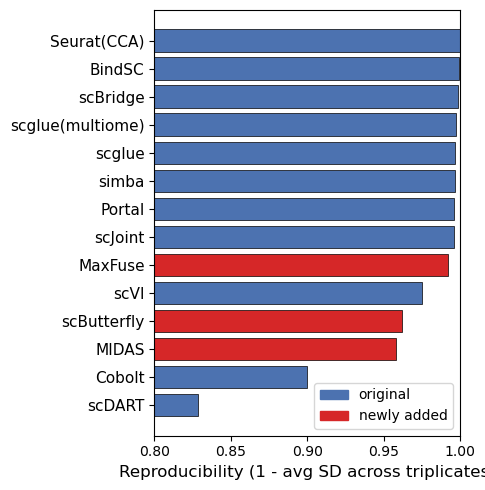

In [6]:
NEW = {'MaxFuse', 'MIDAS', 'scButterfly'}
order = repro.sort_values('reproducibility')['Method'].tolist()      # worst -> best (bottom -> top)
colors = ['#d62728' if m in NEW else '#4c72b0' for m in order]
fig, ax = plt.subplots(figsize=(5, 5))
ax.barh(range(len(order)), repro.set_index('Method').loc[order, 'reproducibility'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=11)
ax.set_xlabel('Reproducibility (1 - avg SD across triplicates)', fontsize=12)
ax.set_xlim(0.8, 1.0)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4c72b0', label='original'), Patch(color='#d62728', label='newly added')],
          loc='lower right', fontsize=10, frameon=True)
plt.tight_layout()
plt.savefig('fig4a_reproducibility_7type.pdf', dpi=300)
plt.savefig('fig4a_reproducibility_7type.png', dpi=200)
plt.show()

# Fig4B — pairwise Louvain NMI across triplicates

Same label sensitivity as Fig4A: the NMI depends on the target cluster count (`nclust` = #cell types)
and on which cells are clustered, so the 7-type label is required to match the published Fig4B.

The published 7-type louvain clusterings are already saved
(`.../HT243B1-S1H4_adj/louvain_cluster_reproduce.csv`), so **10 old methods reuse those cluster
assignments** -> their Fig4B NMI matches the publication *by construction* (NMI is label-free / sklearn-only).
**MIDAS(1/3/4) and Cobolt(1/2/5) are re-selected, so they are clustered here** along with the other new methods (MaxFuse, scButterfly) with the identical pipeline (per-rep `find_louvain_res` to nclust=7,
`sc.pp.neighbors`, `sc.tl.louvain` random_state=420) -- that step needs scanpy + benchmark_fun, so it runs on
the cluster and is skipped gracefully on a laptop.


In [7]:
from itertools import combinations
from sklearn.metrics import normalized_mutual_info_score as nmi_score

OLD_CLUST = '/path/to/reference_tables/brca/louvain_cluster_reproduce.csv'
if not os.path.exists(OLD_CLUST):
    OLD_CLUST = '/path/to/reference_tables/brca/louvain_cluster_reproduce.csv'
old_clu = pd.read_csv(OLD_CLUST, index_col=0)
# Cobolt moved to the fresh-clustering block below (reps 1/2/5 are not in the published 1/2/3 cache).
OLD10 = ['scDART','Seurat(CCA)','BindSC','scBridge','scglue','scglue(multiome)','scJoint','scVI','Portal','simba']

def pair_nmi(clu, reps):
    sub = clu[reps].dropna()
    return [(f'{a} vs {b}', float(nmi_score(sub[a], sub[b]))) for a, b in combinations(reps, 2)]

nmi_rows = []
for m in OLD10:                                  # published clusters -> exact published NMI
    for pair, val in pair_nmi(old_clu, [f'{m}-{r}' for r in (1, 2, 3)]):
        nmi_rows.append({'Method': m, 'Pair': pair, 'NMI': val})
print('old 11 methods: reused published 7-type clusters')

old 11 methods: reused published 7-type clusters


In [8]:
# cluster the 3 NEW methods with the SAME pipeline (needs scanpy + benchmark_fun -> run on the cluster)
try:
    import sys
    import scanpy as sc
    sys.path.append(os.environ.get('BENCHMARK_FUN_DIR', '/path/to/multiomeBench/common'))
    import benchmark_fun
    nclust = labels_annot.loc[labels_annot.index.isin(bc_test), 'cell_type'].nunique()   # = 7
    SEED = 420
    def cluster_rep(lat):
        lt = lat.loc[lat.index.isin(bc_test)]
        a = sc.AnnData(lt); a.obsm['X_emb'] = lt.values
        res = benchmark_fun.find_louvain_res(a, nclust)
        app = a.copy(); sc.pp.neighbors(app); sc.tl.louvain(app, resolution=res, random_state=SEED)
        return pd.Series(app.obs['louvain'].astype(str).values, index=lt.index)
    for method in ['MaxFuse', 'MIDAS', 'scButterfly', 'Cobolt']:
        cols = {f'{method}-{r}': cluster_rep(pd.read_csv(p, index_col=0))
                for r, p in enumerate(METHODS[method], 1)}
        cdf = pd.DataFrame(cols)
        for pair, val in pair_nmi(cdf, list(cols)):
            nmi_rows.append({'Method': method, 'Pair': pair, 'NMI': val})
    print('clustered + scored the 3 new methods')
except Exception as e:
    print('scanpy/benchmark_fun unavailable -> new methods skipped (run this on the cluster):', repr(e))

/path/to/home/.conda/envs/benchmark_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


resoultion:  0.09765625  for  7  clusters after  10 iteration


resoultion:  0.0946044921875  for  7  clusters after  15 iteration


resoultion:  0.128173828125  for  7  clusters after  14 iteration


resoultion:  0.390625  for  7  clusters after  8 iteration


...

resoultion:  0.146484375  for  7  clusters after  11 iteration
         Falling back to preprocessing with `sc.pp.pca` and default params.


resoultion:  0.048828125  for  7  clusters after  11 iteration


resoultion:  0.0732421875  for  7  clusters after  12 iteration


resoultion:  0.1953125  for  7  clusters after  9 iteration


clustered + scored the 3 new methods


In [9]:
nmi_df = pd.DataFrame(nmi_rows)
nmi_df.to_csv('nmi_df_7type.csv', index=False)
nmi_mean = nmi_df.groupby('Method')['NMI'].mean().sort_values(ascending=False)
print(nmi_mean.round(4).to_string())

Method
Seurat(CCA)         1.0000
BindSC              0.9770
scBridge            0.9538
Portal              0.9433
scJoint             0.9135
scglue(multiome)    0.9123
scglue              0.9068
simba               0.8468
MaxFuse             0.8047
scVI                0.7793
scButterfly         0.7709
MIDAS               0.7013
Cobolt              0.6396
scDART              0.3920


/lsf_tmp/298456274.tmpdir/ipykernel_2761578/2193984002.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=nmi_df, x='Method', y='NMI', order=order, palette=pal, ax=ax)
/lsf_tmp/298456274.tmpdir/ipykernel_2761578/2193984002.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=45, ha='right', fontsize=10)


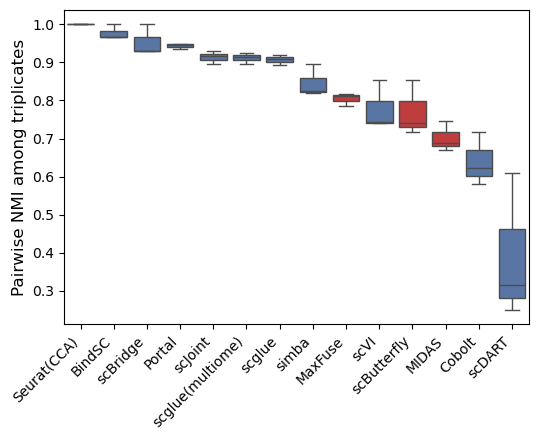

In [10]:
NEW = {'MaxFuse', 'MIDAS', 'scButterfly'}
order = nmi_mean.index.tolist()
pal = {m: ('#d62728' if m in NEW else '#4c72b0') for m in order}
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.boxplot(data=nmi_df, x='Method', y='NMI', order=order, palette=pal, ax=ax)
ax.set_xticklabels(order, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Pairwise NMI among triplicates', fontsize=12); ax.set_xlabel('')
plt.tight_layout()
plt.savefig('fig4b_nmi_7type.pdf', dpi=300); plt.savefig('fig4b_nmi_7type.png', dpi=200)
plt.show()